# XGBoost Regression

XGBoost is an ensemble learning algorithm based on gradient boosting. It builds decision trees sequentially, where each new tree learns from the errors of the previous trees to improve prediction accuracy.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
project_root = Path.cwd().parent              # Data transformed from data transformation

train_path = project_root / "artifacts" / "data_transformation" / "train.npy"
test_path = project_root / "artifacts" / "data_transformation" / "test.npy"

train_arr = np.load(train_path)
test_arr = np.load(test_path)

In [4]:
X_train = train_arr[:, :-1]
y_train = train_arr[:, -1]   # The transformed arrays contain both the input features and the target variable.

X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

In [5]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(436, 14)
(436,)
(109, 14)
(109,)


In [6]:
model = XGBRegressor(
    n_estimators=100,    # it means for 100 decision trees for xgboost
    learning_rate=0.1,   
    max_depth=6,
    random_state=42
)

print(model)

#Learning rate controls how much each new tree contributes to correcting the errors of the previous trees.
# A smaller learning rate makes learning slower but can improve generalization, while a larger learning rate makes learning faster but may lead to overfitting.

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


In [7]:
model.fit(X_train, y_train)

print("XGBoost model trained successfully!") #Train the Model

XGBoost model trained successfully!


In [8]:
y_pred = model.predict(X_test)      #predict the values by using test data

print(y_pred[:5])

[5008081.5 7142124.5 3639525.5 4423721.5 4038112.2]


In [9]:
comparison = pd.DataFrame({                          # compare actual vs predicted
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,4060000.0,5008081.50
1,6650000.0,7142124.50
2,3710000.0,3639525.50
3,6440000.0,4423721.50
4,2800000.0,4038112.25
5,4900000.0,3134213.25
6,5250000.0,5965277.50
7,4543000.0,4786962.50
8,2450000.0,3144115.50
9,3353000.0,3006196.25


In [10]:
mae = mean_absolute_error(y_test, y_pred)      # model evaluation
 
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

MAE : 1023679.19
MSE : 1994700067670.88
RMSE : 1412338.51
R2 Score : 0.6054


In [ ]:
feature_names = [                  # feature names
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus_furnished",
    "furnishingstatus_semi-furnished",
    "furnishingstatus_unfurnished",
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

In [13]:
importance = model.feature_importances_       # feature importance

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
11,bathrooms,0.356392
4,airconditioning,0.113214
9,area,0.107154
8,furnishingstatus_unfurnished,0.076077
3,hotwaterheating,0.067912
12,stories,0.045520
5,prefarea,0.044356
10,bedrooms,0.043835
2,basement,0.042351
13,parking,0.029410


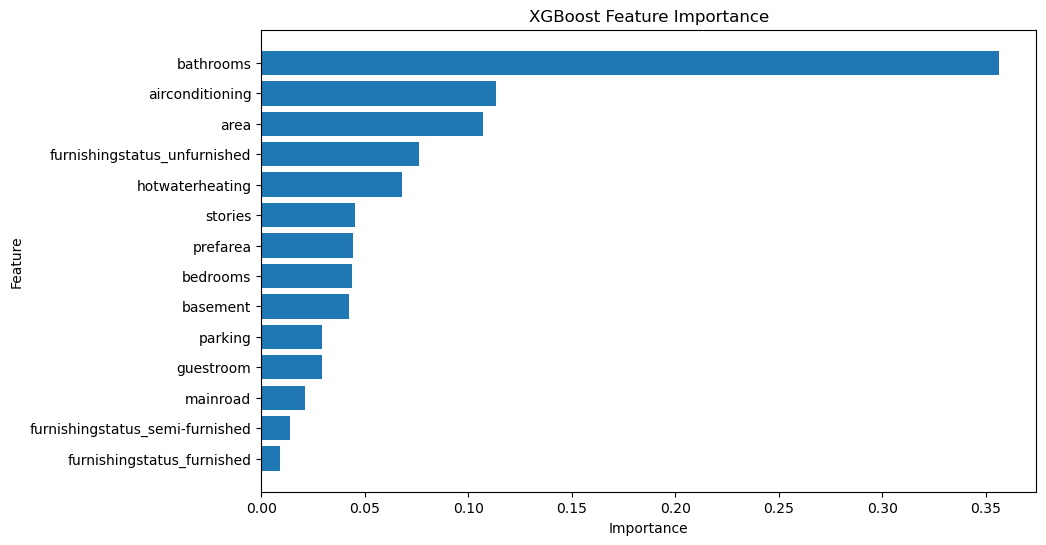

In [14]:
plt.figure(figsize=(10,6))              # checking in plots

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()